UCI Diabetes Dataset - Logistic Regression Results
Accuracy : 0.575
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Pima Diabetes Dataset - Logistic Regression Results
Accuracy : 0.5
Precision: 0.3333
Recall   : 0.0714
F1 Score : 0.1176


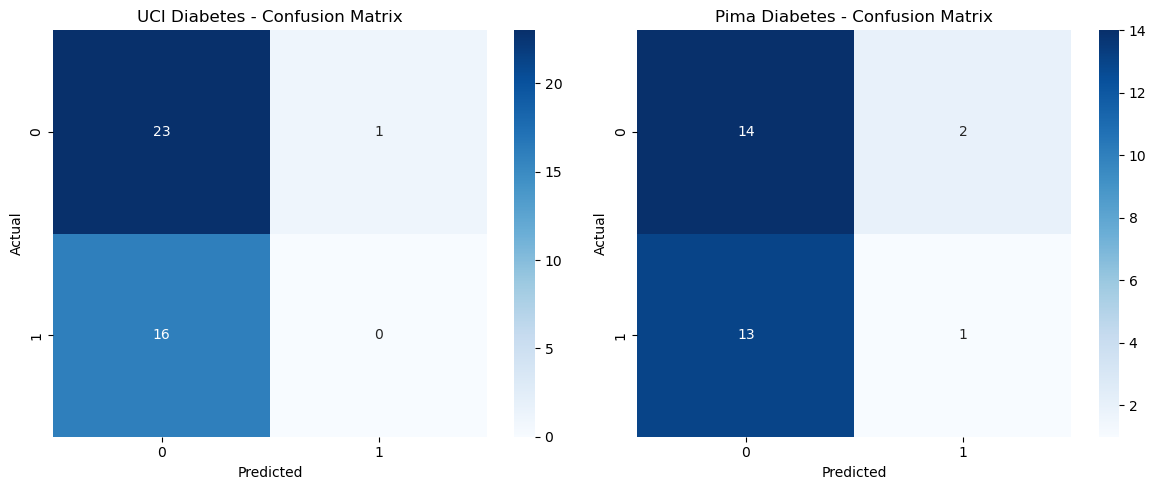

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Create sample UCI Diabetes dataset
np.random.seed(42)
uci_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(70, 200, 200),
    "BloodPressure": np.random.randint(50, 110, 200),
    "BMI": np.round(np.random.uniform(18, 40, 200), 1),
    "Outcome": np.random.randint(0, 2, 200)
})

# Create sample Pima Diabetes dataset
pima_diabetes = pd.DataFrame({
    "Glucose": np.random.randint(70, 200, 150),
    "BloodPressure": np.random.randint(50, 110, 150),
    "BMI": np.round(np.random.uniform(18, 40, 150), 1),
    "Outcome": np.random.randint(0, 2, 150)
})

# Features and Target
features = ["Glucose", "BloodPressure", "BMI"]
target = "Outcome"

X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

# Split Data
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42
)

# Train Models
model_uci = LogisticRegression(max_iter=1000)
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LogisticRegression(max_iter=1000)
model_pima.fit(X_train_pima, y_train_pima)

# Predictions
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

# Evaluation
print("UCI Diabetes Dataset - Logistic Regression Results")
print("Accuracy :", round(accuracy_score(y_test_uci, y_pred_uci), 4))
print("Precision:", round(precision_score(y_test_uci, y_pred_uci), 4))
print("Recall   :", round(recall_score(y_test_uci, y_pred_uci), 4))
print("F1 Score :", round(f1_score(y_test_uci, y_pred_uci), 4))

print("\nPima Diabetes Dataset - Logistic Regression Results")
print("Accuracy :", round(accuracy_score(y_test_pima, y_pred_pima), 4))
print("Precision:", round(precision_score(y_test_pima, y_pred_pima), 4))
print("Recall   :", round(recall_score(y_test_pima, y_pred_pima), 4))
print("F1 Score :", round(f1_score(y_test_pima, y_pred_pima), 4))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test_uci, y_pred_uci),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("UCI Diabetes - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test_pima, y_pred_pima),
            annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Pima Diabetes - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()